In [6]:
!pip install pytrends

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-IN', tz=330)

In [8]:
import pytrends
print("Pytrends installed successfully")

Pytrends installed successfully


In [9]:
pytrends = TrendReq(
    hl='en-IN',
    tz=330
)

print("Google Trends connection initialized")

Google Trends connection initialized


In [10]:
pytrends.build_payload(
    ['Python'],
    cat=0,
    timeframe='today 12-m',
    geo='IN',
    gprop=''
)

In [11]:
data = pytrends.interest_over_time()

data.head()

,Python,isPartial
date,,
2025-09-21,79,False
2025-09-28,63,False
2025-10-05,82,False
2025-10-12,77,False
2025-10-19,59,False


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
data.shape


(53, 2)

In [17]:
data.columns

Index(['Python', 'isPartial'], dtype='str')

In [18]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 53 entries, 2025-09-21 to 2026-09-20
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Python     53 non-null     int64
 1   isPartial  53 non-null     bool 
dtypes: bool(1), int64(1)
memory usage: 901.0 bytes


In [19]:
data.describe()

,Python
count,53.000000
mean,74.056604
std,10.728135
min,57.000000
25%,66.000000
50%,73.000000
75%,82.000000
max,100.000000


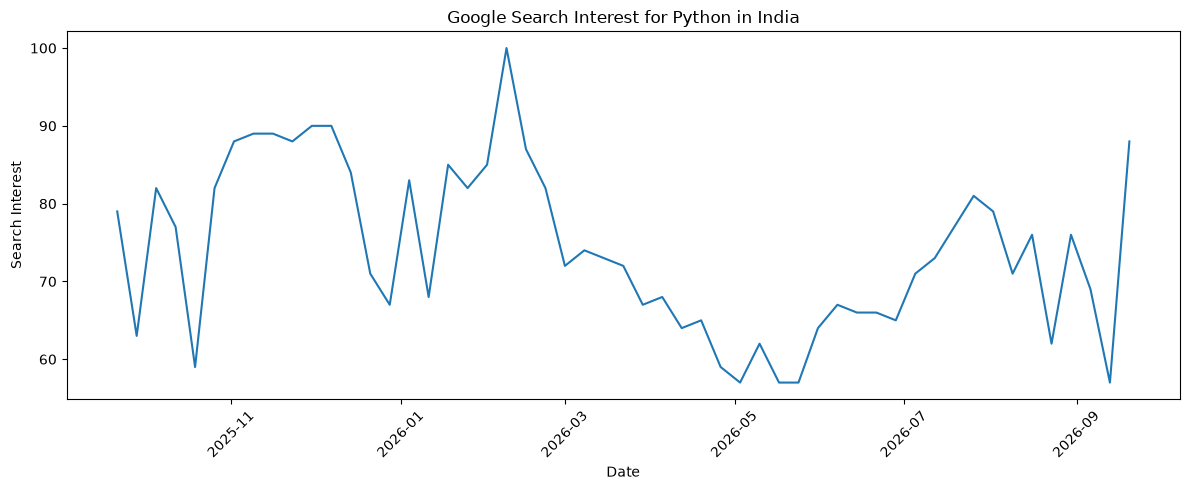

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data['Python'])

plt.title('Google Search Interest for Python in India')
plt.xlabel('Date')
plt.ylabel('Search Interest')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
data.tail()

,Python,isPartial
date,,
2026-08-23,62,False
2026-08-30,76,False
2026-09-06,69,False
2026-09-13,57,False
2026-09-20,88,True


In [22]:
data["Python"].max()

np.int64(100)

In [23]:
data["Python"].idxmax()

Timestamp('2026-02-08 00:00:00')

In [25]:
data["Python"].min()

np.int64(57)

In [27]:
data["Python"].idxmin()

Timestamp('2026-05-03 00:00:00')

In [28]:
highest = data["Python"].max()
lowest = data["Python"].min()

print("Highest Search Interest:", highest)
print("Lowest Search Interest:", lowest)

Highest Search Interest: 100
Lowest Search Interest: 57


In [29]:
difference = highest - lowest

print("Difference:", difference)

Difference: 43


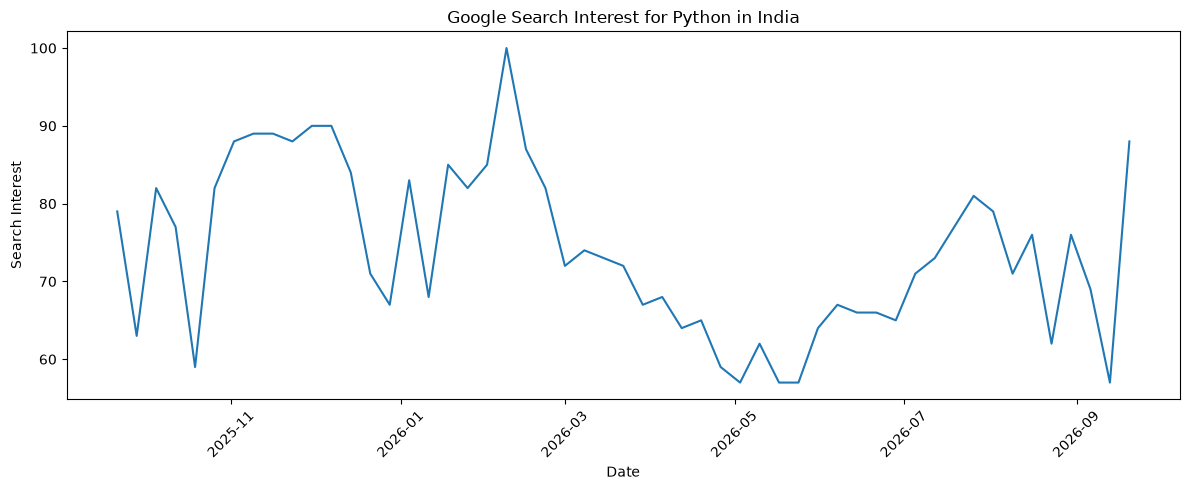

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Python"])

plt.title("Google Search Interest for Python in India")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
data["Python"].sort_values(ascending=False).head(5)

date
2026-02-08    100
2025-12-07     90
2025-11-30     90
2025-11-16     89
2025-11-09     89
Name: Python, dtype: int64

In [32]:
top_5 = data["Python"].sort_values(ascending=False).head(5)

top_5

date
2026-02-08    100
2025-12-07     90
2025-11-30     90
2025-11-16     89
2025-11-09     89
Name: Python, dtype: int64

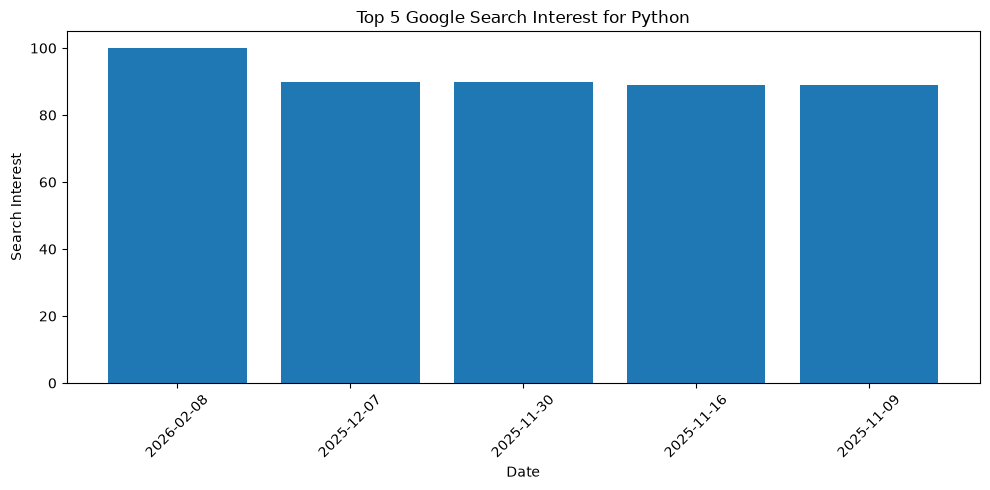

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(top_5.index.astype(str), top_5.values)

plt.title("Top 5 Google Search Interest for Python")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
keywords = [
    "Python",
    "SQL",
    "Power BI",
    "Data Science",
    "Machine Learning"
]

In [35]:
pytrends.build_payload(
    keywords,
    cat=0,
    timeframe='today 12-m',
    geo='IN',
    gprop=''
)

In [37]:

comparison_data = pytrends.interest_over_time()

In [38]:
from pytrends.request import TrendReq

pytrends = TrendReq(
    hl='en-IN',
    tz=330
)

In [39]:
keywords = [
    "Python",
    "SQL",
    "Power BI",
    "Data Science",
    "Machine Learning"
]

In [40]:
pytrends.build_payload(
    keywords,
    cat=0,
    timeframe='today 12-m',
    geo='IN',
    gprop=''
)

In [41]:
comparison_data = pytrends.interest_over_time()

comparison_data.head()

,Python,SQL,Power BI,Data Science,Machine Learning,isPartial
date,,,,,,
2025-09-21,79,35,9,9,8,False
2025-09-28,63,27,7,9,7,False
2025-10-05,82,35,9,9,8,False
2025-10-12,77,32,9,10,8,False
2025-10-19,59,23,7,8,7,False


In [42]:
comparison_data.mean(numeric_only=True)

Python              74.075472
SQL                 28.716981
Power BI             8.113208
Data Science        11.150943
Machine Learning    11.377358
isPartial            0.018868
dtype: float64

In [43]:
comparison_data.mean(numeric_only=True)

Python              74.075472
SQL                 28.716981
Power BI             8.113208
Data Science        11.150943
Machine Learning    11.377358
isPartial            0.018868
dtype: float64

In [44]:
average_interest = comparison_data.mean(numeric_only=True)

average_interest

Python              74.075472
SQL                 28.716981
Power BI             8.113208
Data Science        11.150943
Machine Learning    11.377358
isPartial            0.018868
dtype: float64

In [45]:
average_interest = average_interest.sort_values(ascending=False)

average_interest

Python              74.075472
SQL                 28.716981
Machine Learning    11.377358
Data Science        11.150943
Power BI             8.113208
isPartial            0.018868
dtype: float64

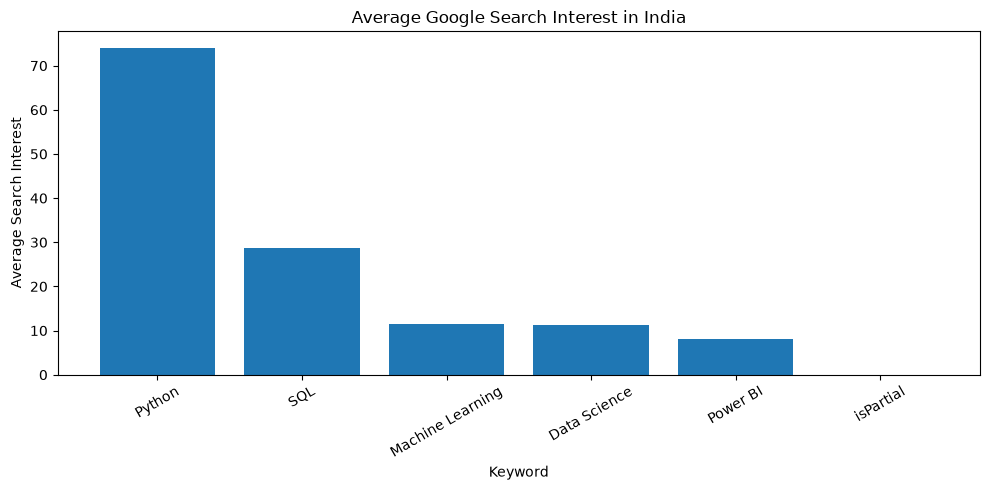

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(average_interest.index, average_interest.values)

plt.title("Average Google Search Interest in India")
plt.xlabel("Keyword")
plt.ylabel("Average Search Interest")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [47]:
max_interest = comparison_data.max(numeric_only=True)

max_interest

Python               100
SQL                   39
Power BI              12
Data Science          15
Machine Learning      19
isPartial           True
dtype: object

In [48]:
min_interest = comparison_data.min(numeric_only=True)

min_interest

Python                 57
SQL                    21
Power BI                6
Data Science            8
Machine Learning        7
isPartial           False
dtype: object

In [50]:
numeric_only=True

In [51]:
keywords_data = comparison_data[
    ["Python", "SQL", "Power BI", "Data Science", "Machine Learning"]
]

In [52]:
max_interest = keywords_data.max()

max_interest

Python              100
SQL                  39
Power BI             12
Data Science         15
Machine Learning     19
dtype: int64

In [53]:
max_dates = keywords_data.idxmax()

max_dates

Python             2026-02-08
SQL                2025-11-09
Power BI           2025-11-16
Data Science       2026-05-31
Machine Learning   2026-02-15
dtype: datetime64[s]

In [54]:
summary = pd.DataFrame({
    "Maximum Interest": keywords_data.max(),
    "Peak Date": keywords_data.idxmax()
})

summary

,Maximum Interest,Peak Date
Python,100,2026-02-08
SQL,39,2025-11-09
Power BI,12,2025-11-16
Data Science,15,2026-05-31
Machine Learning,19,2026-02-15


In [55]:
max_dates = keywords_data.idxmax()
max_dates

Python             2026-02-08
SQL                2025-11-09
Power BI           2025-11-16
Data Science       2026-05-31
Machine Learning   2026-02-15
dtype: datetime64[s]

In [56]:
summary = pd.DataFrame({
    "Maximum Interest": keywords_data.max(),
    "Peak Date": keywords_data.idxmax()
})

summary

,Maximum Interest,Peak Date
Python,100,2026-02-08
SQL,39,2025-11-09
Power BI,12,2025-11-16
Data Science,15,2026-05-31
Machine Learning,19,2026-02-15


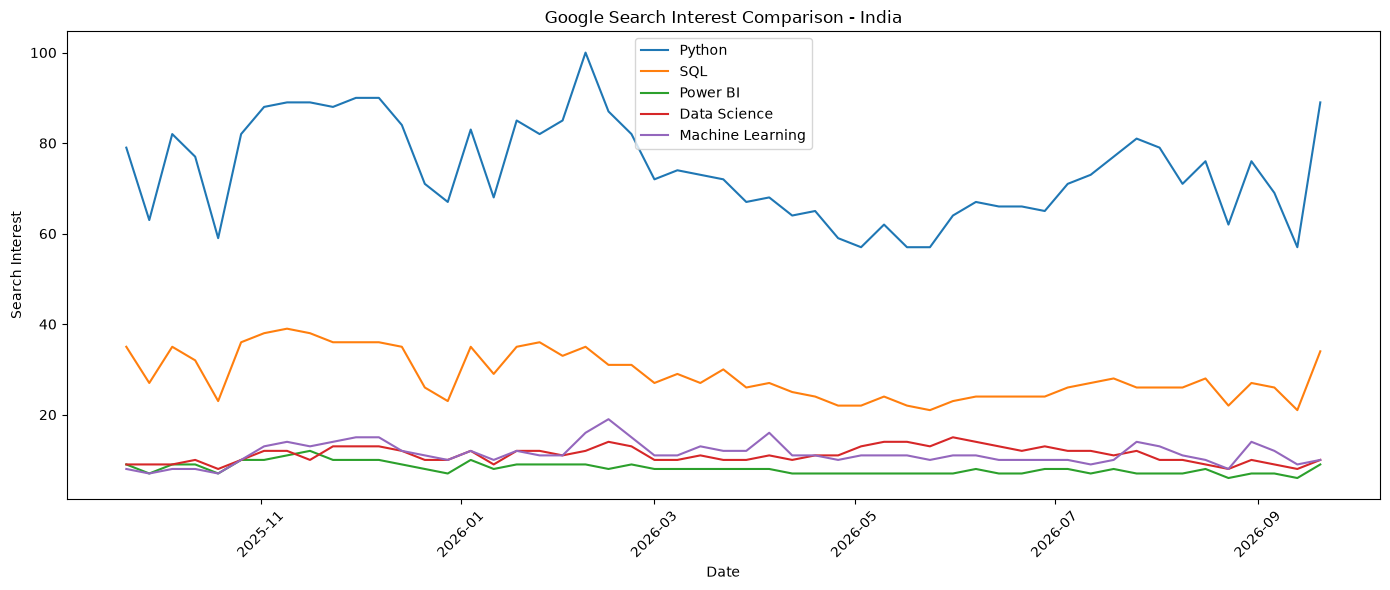

In [57]:
plt.figure(figsize=(14, 6))

for keyword in keywords_data.columns:
    plt.plot(
        keywords_data.index,
        keywords_data[keyword],
        label=keyword
    )

plt.title("Google Search Interest Comparison - India")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()